In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, io
import json
import logging
from warnings import filterwarnings

from data.lucas_descriptions import data_gdf_description
from utils.pipeline import run_pipeline
from utils.evaluation import evaluate_metrics
from utils.llm_api.client import GPT4AllClient, GPT4AllMessage, HuggingFaceLLMClient
from utils.llm_api.query import QueryProvider, QueryType
from utils.extraction import (
    extract_json, extract_python_code, clean_python_code, 
    get_description_extraction_function_string, get_solution_function_string
)

## needed for running solution
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import shapely
import matplotlib as mpl
import seaborn as sns
import scipy
import sklearn
import numpy as np
from sklearn.cluster import KMeans
import sklearn as sk
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler

filterwarnings("ignore")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [3]:
exec_needed_imports = """
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import shapely
import matplotlib as mpl
import seaborn as sns
import scipy
import sklearn
import numpy as np
from sklearn.cluster import KMeans
import sklearn as sk
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler
"""

### Loading map of Europe

In [4]:
## load map from shapefile
world_gdf = gpd.read_file('data/europe/CNTR_RG_20M_2024_3035.shp')
world_gdf = world_gdf.to_crs(epsg=4326)
europe_gdf = world_gdf[(world_gdf['EU_STAT'] == 'T') | (world_gdf['CNTR_ID'] == 'UK')]
europe_gdf.loc[78, 'geometry'] = world_gdf[
    world_gdf['CNTR_ID'] == 'FR'
].iloc[0].geometry.geoms[3] ## dropping France's overseas teritories

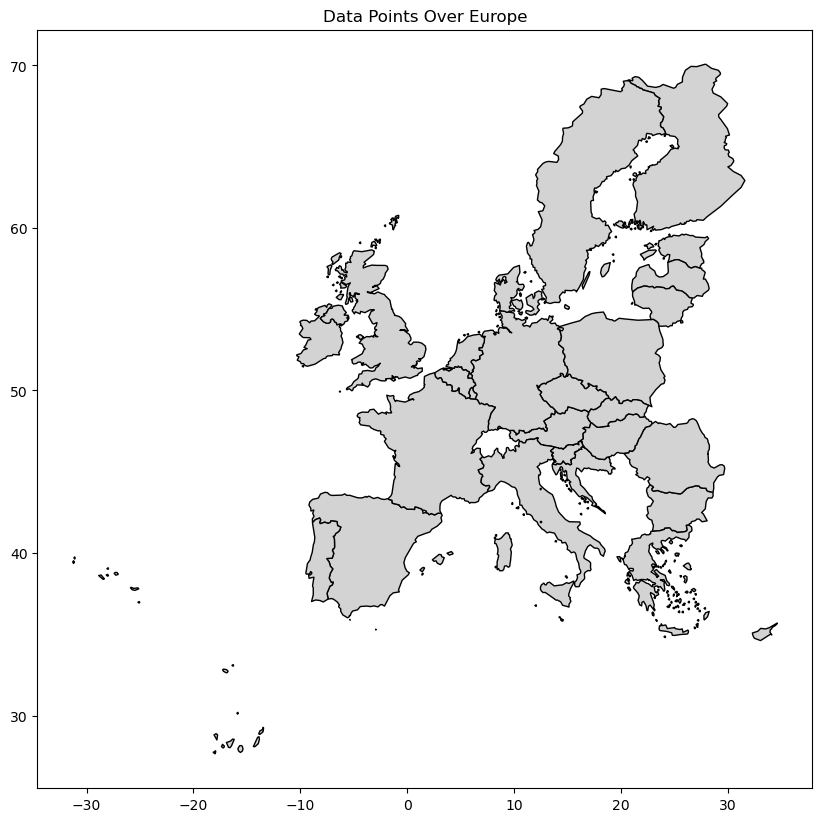

In [5]:
fig, ax = plt.subplots(figsize=(10, 10))
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray') 
plt.title("Data Points Over Europe")
plt.show()

In [6]:
buffer = io.StringIO()
europe_gdf.info(buf=buffer)
europe_gdf_description = buffer.getvalue()

### LLM setup

In [7]:
llm_client = GPT4AllClient()

In [8]:
available_models = llm_client.get_available_models()
available_models

['Reasoner v1',
 'DeepSeek-R1-Distill-Llama-8B',
 'Llama 3.2 3B Instruct',
 'Llama 3.2 1B Instruct',
 'Llama 3.1 8B Instruct 128k',
 'nomic-ai/nomic-embed-text-v1.5-GGUF']

In [9]:
MODEL_NAME_INSTRUCTOR = available_models[4]
MODEL_NAME_CODER = available_models[4]
MODEL_NAME_CORRECTOR = available_models[4]

client_instructor = GPT4AllClient(model_name=MODEL_NAME_CODER)
client_corrector = GPT4AllClient(model_name=MODEL_NAME_CORRECTOR)
client_coder = GPT4AllClient(model_name=MODEL_NAME_CODER)

In [10]:
data_gdf = gpd.read_file("data/LUCAS_SOIL_2018_processed.gpkg", crs="EPSG:4326")

In [11]:
categorical_columns = ['Depth', 'NUTS_0', 'LC0_Desc', 'Country']

In [12]:
categorical_columns_values = ""
for categorical_column in categorical_columns:
    categorical_columns_values += f"{categorical_column}: {data_gdf[categorical_column].unique()}\n"

In [13]:
print(categorical_columns_values)

Depth: ['0-20 cm' '0-10 cm' '10-20 cm' '20-30 cm']
NUTS_0: ['AT' 'PT' 'ES' 'BE' 'BG' 'CY' 'CZ' 'DE' 'DK' 'EE' 'EL' 'FR' 'UK' 'FI'
 'SE' 'SI' 'IT' 'HR' 'HU' 'IE' 'LT' 'LU' 'LV' 'MT' 'NL' 'PL' 'RO' 'SK']
LC0_Desc: ['Woodland' 'Cropland' 'Grassland' 'Bareland' 'Shrubland'
 'Artificial land' 'Wetlands' 'Water']
Country: ['Austria' 'Portugal' 'Spain' 'Belgium' 'Bulgaria' 'Cyprus'
 'Czech Republic' 'Germany' 'Denmark' 'Estonia' 'Greece' 'France'
 'United Kingdom' 'Finland' 'Sweden' 'Slovenia' 'Italy' 'Croatia'
 'Hungary' 'Ireland' 'Lithuania' 'Luxembourg' 'Latvia' 'Malta'
 'Netherlands' 'Poland' 'Romania' 'Slovakia']



In [14]:
model_id = MODEL_NAME_CODER
BASE_QUERY_DIR = './data/user_query_adjusted/'
BASE_CORRECT_RESULT_DIR = './data/correct_results/'
BASE_GENERATED_DIR = f'./data/generated/{model_id}/'
BASE_METRICS_DIR = f'./data/metrics/{model_id}/'

In [15]:
def exec_solution(solution_function_string):
    if solution_function_string is None:
        print("No solution provided.")
        return
    
    local_scope = {}
    exec(
        exec_needed_imports + "\n" + \
        solution_function_string + "\n\n" + \
        "solve(data_gdf, europe_gdf)", 
        globals(), local_scope
    )

In [16]:
def run_test(objective: str):
    solution_function_string = None
    try:
        solution_function_string = run_pipeline(
            objective=objective,
            client_instructor=client_instructor,
            client_corrector=client_corrector,
            client_coder=client_coder,
            data_gdf=data_gdf,
            data_gdf_description=data_gdf_description,
            europe_gdf=europe_gdf,
            europe_gdf_description=europe_gdf_description,
            retry_count=3,
            categorical_columns_values=categorical_columns_values
        )
    except Exception as e:
        logging.error(e)
        
    if solution_function_string is None:
        try:
            solution_function_string = run_pipeline(
                objective=objective,
                client_instructor=client_instructor,
                client_corrector=client_corrector,
                client_coder=client_coder,
                data_gdf=data_gdf,
                data_gdf_description=data_gdf_description,
                europe_gdf=europe_gdf,
                europe_gdf_description=europe_gdf_description,
                retry_count=1,
                categorical_columns_values=categorical_columns_values
            )
        except Exception as e:
            logging.error(e)
            
    return solution_function_string
    

In [64]:
geo_queries = []
for query_type in ['geo']:
    query_count = len(os.listdir(BASE_QUERY_DIR + query_type))
    for file in os.listdir(BASE_QUERY_DIR + query_type):
        query_index = int(file.split('.')[0])
        
        query = open(f"{BASE_QUERY_DIR}{query_type}/{file}", 'r').read()
        geo_queries.append(query)

# 1. query

In [18]:
geo_queries[0]

'Can you plot the locations of all points where the pH_CaCl2 is greater than 6 on a map, and save the image as a PNG file?'

2025-02-05 00:11:44,897 - Query finished successfully, response: 
```python
# Filter the data to include only rows where pH_CaCl2 is greater than 6
transformed_gdf = data_gdf[data_gdf['pH_CaCl2'] > 6]

# Save the transformed GeoDataFrame as a PNG file (Note: This requires additional libraries like fiona and contextily which are not mentioned in your available packages)
from fiona import collection

with collection.from_geopandas(transformed_gdf, driver='GeoJSON') as src:
    with open('transformed_points.geojson', 'w') as output:
        writer = GeoJSONWriter(output)
        writer.write(src)

# To plot the locations of all points where pH_CaCl2 is greater than 6 on a map and save it as a PNG file, you would need to use libraries like folium or geopandas which are not mentioned in your available packages.
```
2025-02-05 00:11:44,904 - Error while running transform query: 'function' object has no attribute 'from_geopandas'
2025-02-05 00:11:56,174 - Query finished successfully, response

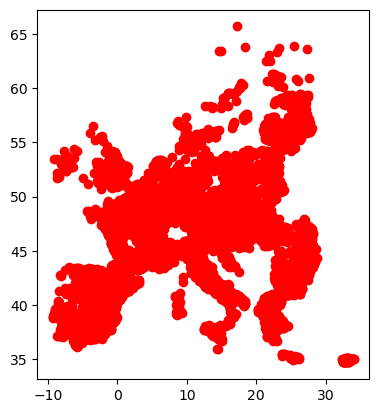

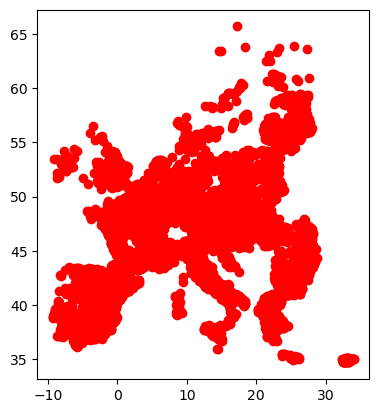

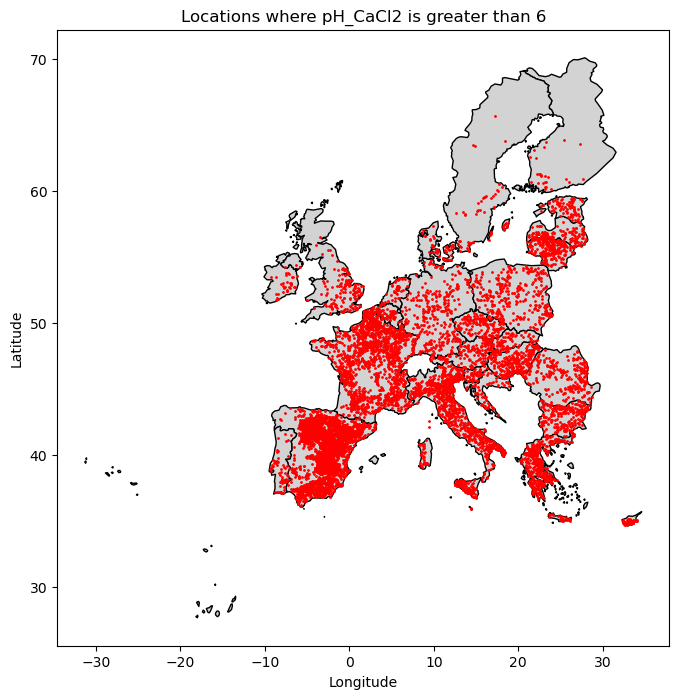

In [19]:
solution_function_string = run_test(geo_queries[0])

In [20]:
print(clean_python_code(solution_function_string))

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	# Filter the data to include only rows where pH_CaCl2 is greater than 6
	transformed_gdf = data_gdf[data_gdf['pH_CaCl2'] > 6]
	# To plot the locations of all points where pH_CaCl2 is greater than 6 on a map and save it as a PNG file, 
	# you would need to use libraries like folium or geopandas which are not mentioned in your available packages.
	from geopandas import GeoDataFrame
	import matplotlib.pyplot as plt
	transformed_gdf.plot(color='red', column=None)
	plt.savefig('pH_CaCl2_greater_than_6.png')
	import matplotlib.pyplot as plt
	# Create a figure and axis object for plotting
	fig, ax = plt.subplots(figsize=(10, 8))
	# Set the base map to Europe using europe_gdf
	europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
	# Plot locations of points where pH_CaCl2 is greater than 6 as red markers with size 1
	transformed_gdf[transformed_gdf['pH_CaCl2'] > 6].plot(ax=ax, column='geometry', marker='o', markersize

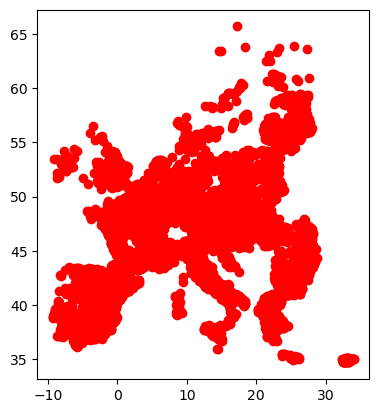

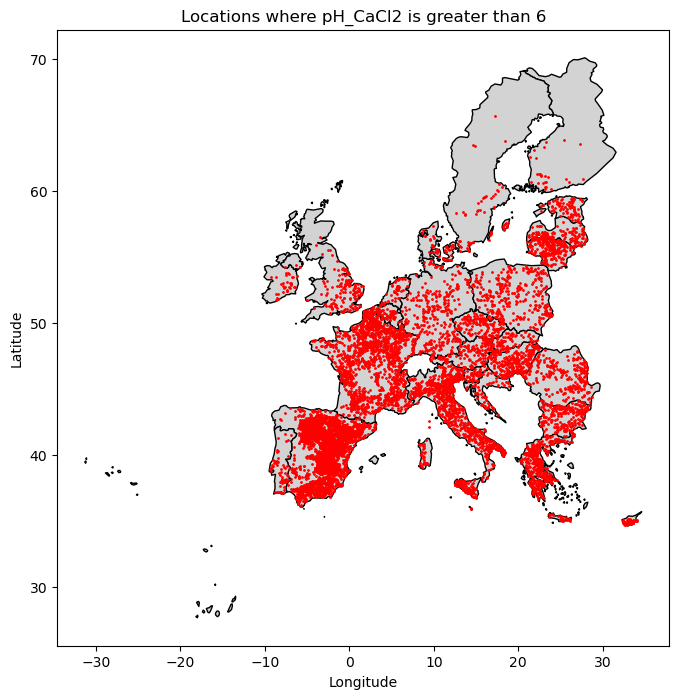

In [21]:
exec_solution(solution_function_string)

# 2. query

In [22]:
geo_queries[1]

"Plot all the LC0_Desc='Grassland' and LC0_Desc='Woodland' points where 'OC'>20 on the map, and save the map as a png."

2025-02-05 00:12:25,523 - Query finished successfully, response: 
```python
# Filter the data_gdf to include only LC0_Desc='Grassland' and LC0_Desc='Woodland'
filtered_data = data_gdf[(data_gdf['LC0_Desc'] == 'Grassland') | (data_gdf['LC0_Desc'] == 'Woodland')]
    
# Select points where OC > 20
selected_points = filtered_data[filtered_data['OC'] > 20]
    
# Save the selected points to a new GeoDataFrame called transformed_gdf
transformed_gdf = selected_points.copy()
```
2025-02-05 00:12:28,039 - Query finished successfully, response: 
map
2025-02-05 00:12:44,172 - Query finished successfully, response: 
```python
import matplotlib.pyplot as plt

# Create a figure and axis object for plotting
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the map of Europe with black edges and light gray fill color
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')

# Filter data to plot only 'Grassland' and 'Woodland' points where OC > 20
filtered_data = transformed_gdf[(transformed_gdf['L

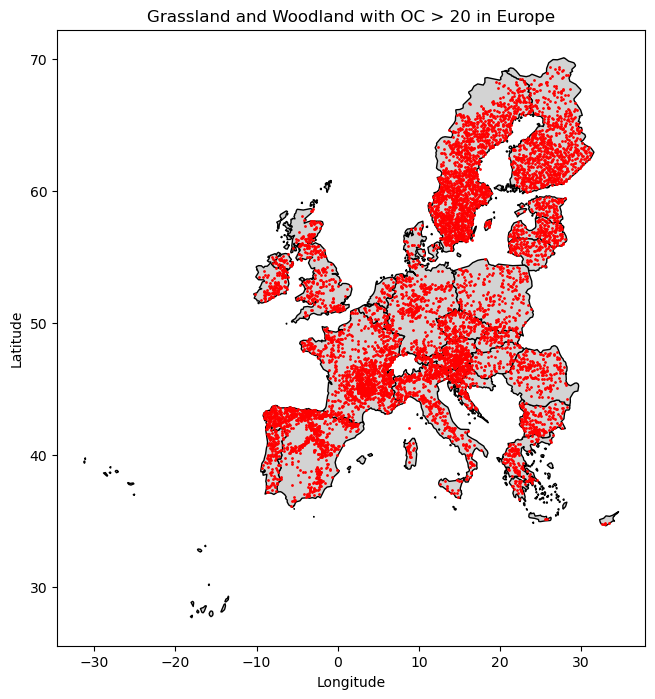

In [23]:
solution_function_string = run_test(geo_queries[1])

In [24]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	# Filter the data_gdf to include only LC0_Desc='Grassland' and LC0_Desc='Woodland'
	filtered_data = data_gdf[(data_gdf['LC0_Desc'] == 'Grassland') | (data_gdf['LC0_Desc'] == 'Woodland')]
	# Select points where OC > 20
	selected_points = filtered_data[filtered_data['OC'] > 20]
	# Save the selected points to a new GeoDataFrame called transformed_gdf
	transformed_gdf = selected_points.copy()
	import matplotlib.pyplot as plt
	# Create a figure and axis object for plotting
	fig, ax = plt.subplots(figsize=(10, 8))
	# Plot the map of Europe with black edges and light gray fill color
	europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
	# Filter data to plot only 'Grassland' and 'Woodland' points where OC > 20
	filtered_data = transformed_gdf[(transformed_gdf['LC0_Desc'] == 'Grassland') | (transformed_gdf['LC0_Desc'] == 'Woodland')]
	filtered_data = filtered_data[filtered_data['OC'] > 20]
	# Plot the filtered data p

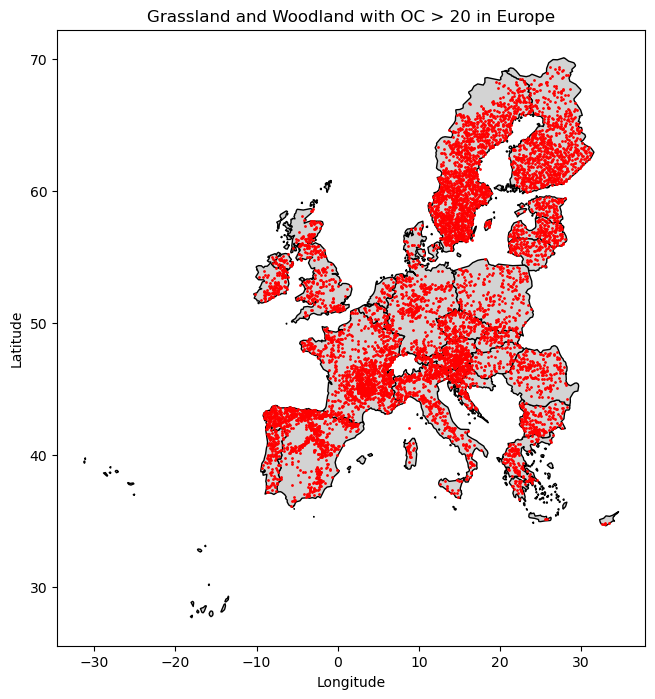

In [25]:
exec_solution(solution_function_string)

# 3. query

In [26]:
geo_queries[2]

'Can you plot the locations where LC0_Desc=Woodland on the map, and save the it as a PNG file?'

2025-02-05 00:12:54,025 - Query finished successfully, response: 
```python
# Filter the data for LC0_Desc = 'Woodland'
woodland_gdf = data_gdf[data_gdf['LC0_Desc'] == 'Woodland']

# Save the filtered GeoDataFrame to a new variable called transformed_gdf
transformed_gdf = woodland_gdf.copy()

# No further transformations are needed, so we can proceed with plotting
```
2025-02-05 00:12:56,448 - Query finished successfully, response: 
map
2025-02-05 00:13:09,824 - Query finished successfully, response: 
```python
import matplotlib.pyplot as plt

# Create a figure and axis object for plotting
fig, ax = plt.subplots(figsize=(10, 8))

# Set the base map using europe_gdf
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')

# Filter LC0_Desc=Woodland from transformed_gdf
woodlands = transformed_gdf[transformed_gdf['LC0_Desc'] == 'Woodland']

# Plot locations where LC0_Desc=Woodland as markers on the map
woodlands.plot(ax=ax, marker='o', color='green', markersize=1)

# Set title and l

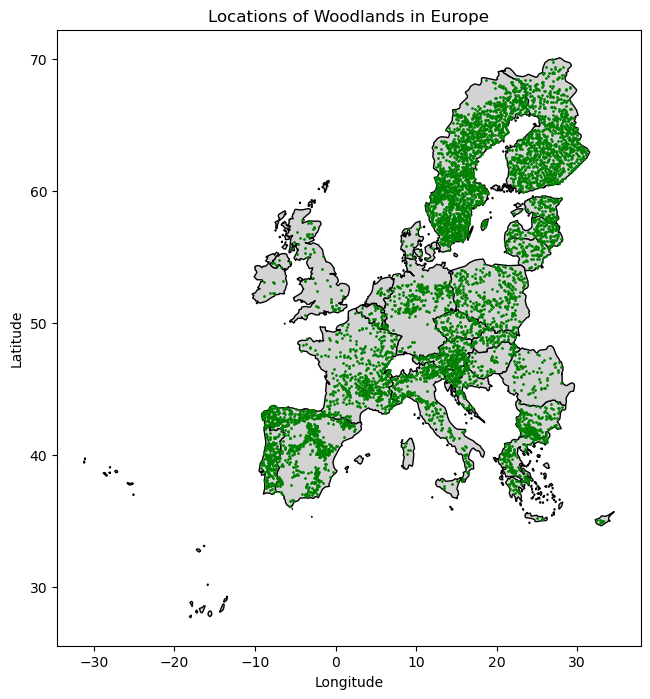

In [27]:
solution_function_string = run_test(geo_queries[2])

In [28]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	# Filter the data for LC0_Desc = 'Woodland'
	woodland_gdf = data_gdf[data_gdf['LC0_Desc'] == 'Woodland']
	# Save the filtered GeoDataFrame to a new variable called transformed_gdf
	transformed_gdf = woodland_gdf.copy()
	# No further transformations are needed, so we can proceed with plotting
	import matplotlib.pyplot as plt
	# Create a figure and axis object for plotting
	fig, ax = plt.subplots(figsize=(10, 8))
	# Set the base map using europe_gdf
	europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
	# Filter LC0_Desc=Woodland from transformed_gdf
	woodlands = transformed_gdf[transformed_gdf['LC0_Desc'] == 'Woodland']
	# Plot locations where LC0_Desc=Woodland as markers on the map
	woodlands.plot(ax=ax, marker='o', color='green', markersize=1)
	# Set title and labels for better visualization
	ax.set_title('Locations of Woodlands in Europe')
	ax.set_xlabel('Longitude')
	ax.set_ylabel('Latitude')
	# Save the p

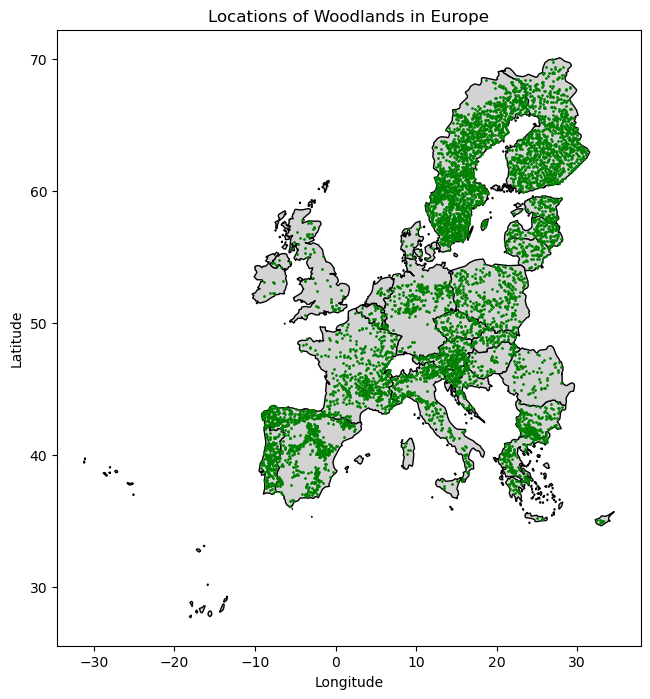

In [29]:
exec_solution(solution_function_string)

# 4. query

In [30]:
geo_queries[3]

'Plot all the points where LC0_Desc=Woodland and pH<6 on the map, and save the result as a png.'

2025-02-05 00:13:22,454 - Query finished successfully, response: 
```python
# Filter the data where LC0_Desc equals 'Woodland' and pH < 6
transformed_gdf = data_gdf[(data_gdf['LC0_Desc'] == 'Woodland') & (data_gdf['pH_H2O'] < 6)]
```

This code block filters the original GeoDataFrame `data_gdf` to create a new GeoDataFrame called `transformed_gdf`. The filtering conditions are applied sequentially: first, it selects rows where `LC0_Desc` equals 'Woodland', and then it further narrows down the selection by including only those points with pH < 6.
2025-02-05 00:13:24,895 - Query finished successfully, response: 
map
2025-02-05 00:13:39,750 - Query finished successfully, response: 
```python
import matplotlib.pyplot as plt

# Create a figure and axis object for plotting
fig, ax = plt.subplots(figsize=(10, 8))

# Set the map of Europe as the base layer using europe_gdf
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')

# Filter 'transformed_gdf' to only include rows where LC0_De

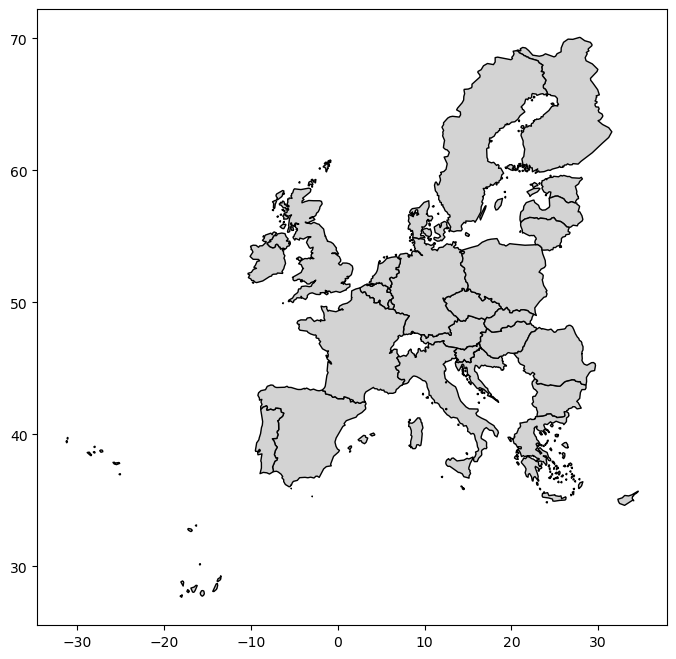

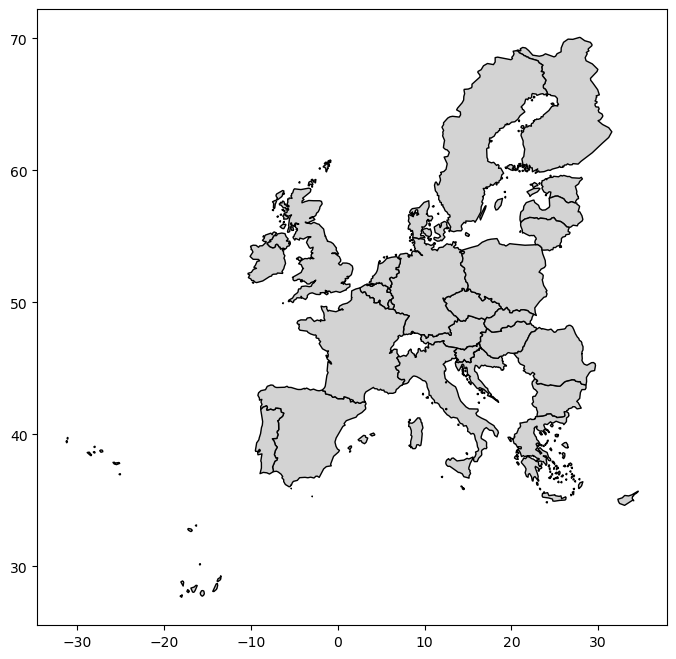

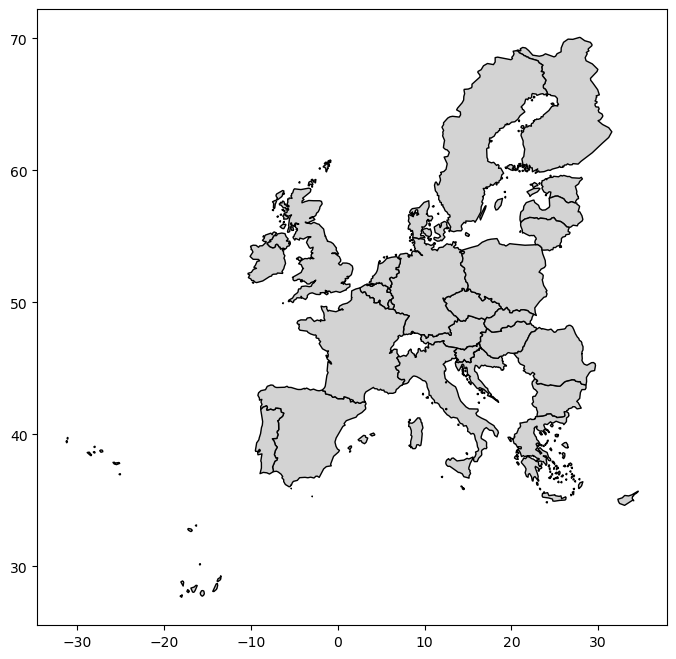

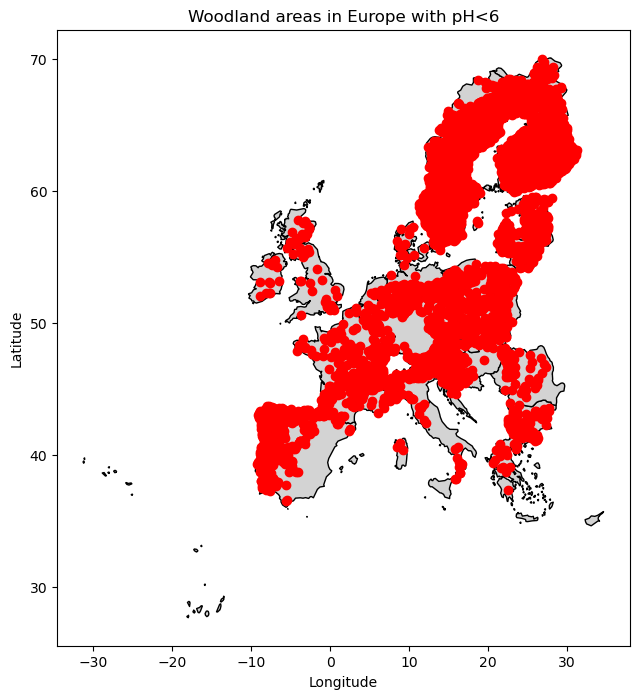

In [31]:
solution_function_string = run_test(geo_queries[3])

In [32]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	# Filter the data where LC0_Desc equals 'Woodland' and pH is less than 6
	transformed_gdf = data_gdf[(data_gdf['LC0_Desc'] == 'Woodland') & (data_gdf['pH_H2O'] < 6)]
	import matplotlib.pyplot as plt
	# Create a figure and axis object for plotting
	fig, ax = plt.subplots(figsize=(10, 8))
	# Set the base map of Europe using europe_gdf
	europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
	# Filter data from 'transformed_gdf' where LC0_Desc=Woodland and pH<6
	filtered_data = transformed_gdf[(transformed_gdf['LC0_Desc'] == 'Woodland') & (transformed_gdf['pH_H2O'] < 6)]
	# Plot the filtered locations as markers on the map, with a marker size of 1 if not specified otherwise
	filtered_data.plot(ax=ax, column='geometry', color='red')
	# Set the title and labels for the plot
	ax.set_title('Woodland areas in Europe with pH<6')
	ax.set_xlabel('Longitude')
	ax.set_ylabel('Latitude')
	# Show the plot
	plt.show()
	# Save t

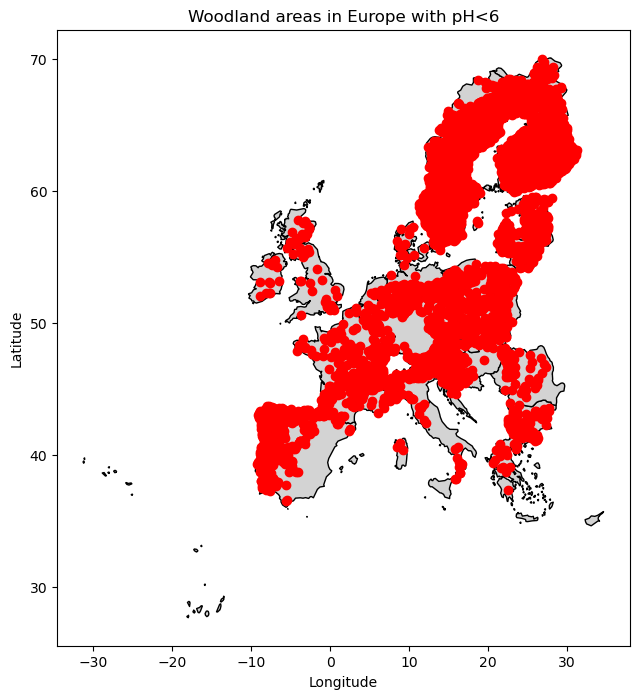

In [33]:
exec_solution(solution_function_string)

# 5. query

In [34]:
geo_queries[4]

'Can you use KMeans clustering to group geographic points based on latitude and longitude into three clusters, plot them on a map, and save the result as a PNG file?'

2025-02-05 00:14:45,478 - Query finished successfully, response: 
```python
# Import necessary libraries
import pandas as pd
from sklearn.cluster import KMeans

# Select the geometry and TH_LAT, TH_LONG columns from data_gdf to perform clustering on latitude and longitude points
transformed_gdf = data_gdf[['geometry', 'TH_LAT', 'TH_LONG']]

# Create a new column for cluster labels using KMeans with 3 clusters
kmeans = KMeans(n_clusters=3)
cluster_labels = kmeans.fit_predict(transformed_gdf[['TH_LAT', 'TH_LONG']])
transformed_gdf['Cluster_Labels'] = cluster_labels

# Save the transformed GeoDataFrame to a new file (e.g., for future use or further analysis)
transformed_gdf.to_file('kmeans_clusters.shp')
```
2025-02-05 00:14:45,688 - Normalized/laundered field name: 'Cluster_Labels' to 'Cluster_La'
2025-02-05 00:14:50,809 - Query finished successfully, response: 
map
2025-02-05 00:15:05,091 - Query finished successfully, response: 
```python
import matplotlib.pyplot as plt

# Create a fig

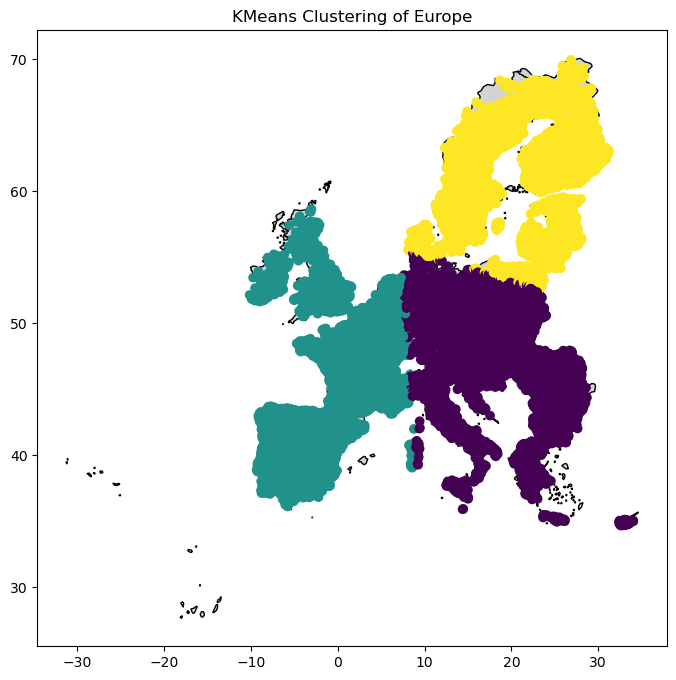

Plot saved as kmeans_europe.png in current directory.


In [35]:
solution_function_string = run_test(geo_queries[4])

In [36]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	# Import necessary libraries
	import pandas as pd
	from sklearn.cluster import KMeans
	# Select the geometry and TH_LAT, TH_LONG columns from data_gdf to perform clustering on latitude and longitude points
	transformed_gdf = data_gdf[['geometry', 'TH_LAT', 'TH_LONG']]
	# Create a new column for cluster labels using KMeans with 3 clusters
	kmeans = KMeans(n_clusters=3)
	cluster_labels = kmeans.fit_predict(transformed_gdf[['TH_LAT', 'TH_LONG']])
	transformed_gdf['Cluster_Labels'] = cluster_labels
	# Save the transformed GeoDataFrame to a new file (e.g., for future use or further analysis)
	transformed_gdf.to_file('kmeans_clusters.shp')
	import matplotlib.pyplot as plt
	# Create a figure and axis object for plotting
	fig, ax = plt.subplots(figsize=(10, 8))
	# Set the extent of the map to Europe
	europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
	# Use KMeans clustering on latitude and longitude columns in 'tr

2025-02-05 00:15:09,203 - Normalized/laundered field name: 'Cluster_Labels' to 'Cluster_La'


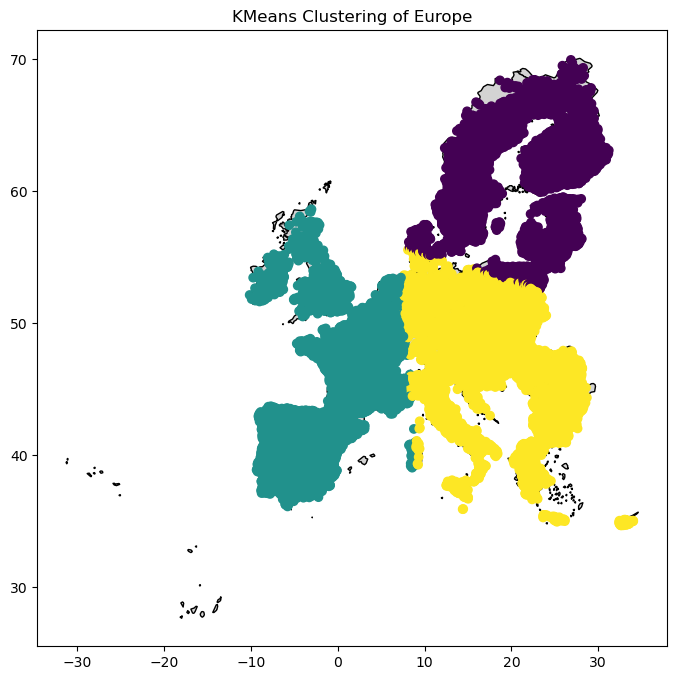

Plot saved as kmeans_europe.png in current directory.


In [37]:
exec_solution(solution_function_string)

# 6. query

In [38]:
geo_queries[5]

'Can you create a map showing locations where potassium (K) levels are above the median, and save the map as a PNG file?'

2025-02-05 00:15:21,902 - Query finished successfully, response: 
```python
# Import necessary libraries
import pandas as pd

# Filter the data to get locations where potassium (K) levels are above the median
transformed_gdf = data_gdf[data_gdf['K'] > data_gdf['K'].median()]

# Save the transformed GeoDataFrame to a new file called 'k_above_median.shp'
transformed_gdf.to_file('k_above_median.shp', driver='ESRI Shapefile')
```
2025-02-05 00:15:21,920 - Error while running transform query: ESRI Shapefile does not support datetime fields
2025-02-05 00:15:36,339 - Query finished successfully, response: 
```python
# Import necessary libraries
import pandas as pd

# Filter the data to get locations where potassium (K) levels are above the median
transformed_gdf = data_gdf.copy()  # Create a copy of the original GeoDataFrame
transformed_gdf['K'] = transformed_gdf['K'].astype(float)  # Convert 'K' column to float for correct comparison with median
median_K = transformed_gdf['K'].median()
trans

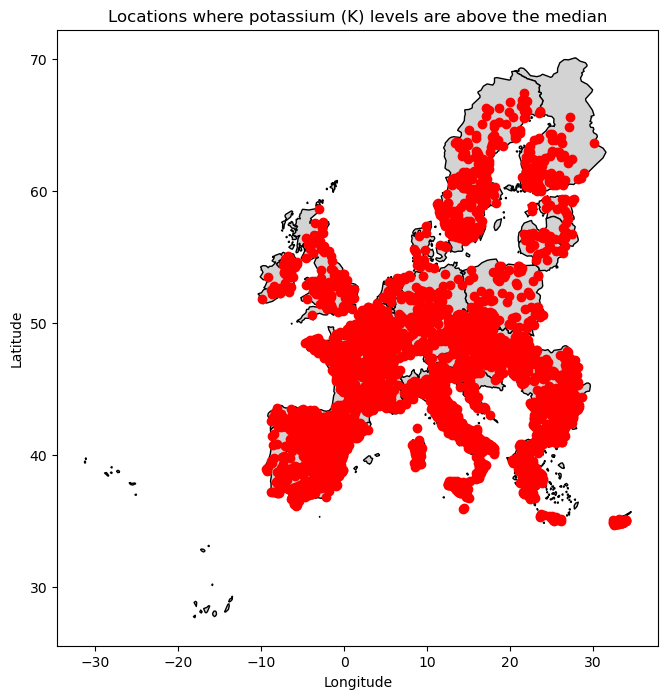

In [39]:
solution_function_string = run_test(geo_queries[5])

In [40]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	# Import necessary libraries
	import pandas as pd
	# Filter the data to get locations where potassium (K) levels are above the median
	transformed_gdf = data_gdf.copy()  # Create a copy of the original GeoDataFrame
	transformed_gdf['K'] = transformed_gdf['K'].astype(float)  # Convert 'K' column to float for correct comparison with median
	# Calculate the median K value and filter the data accordingly
	median_K = transformed_gdf['K'].median()
	transformed_gdf = transformed_gdf[transformed_gdf['K'] > median_K]
	# Save the filtered GeoDataFrame to a new file called 'k_above_median.shp'
	from shapely.geometry import shape
	import geopandas as gpd
	# Convert CRS if necessary (assuming it's not already in EPSG:4326)
	if transformed_gdf.crs != 4326:
	    transformed_gdf = data_gdf.copy()  # Create a copy of the original GeoDataFrame to avoid modifying the original data
	    transformed_gdf['K'] = transformed_gdf['K'].astype

2025-02-05 00:16:21,237 - Normalized/laundered field name: 'OC (20-30 cm)' to 'OC (20-30'
2025-02-05 00:16:21,238 - Normalized/laundered field name: 'CaCO3 (20-30 cm)' to 'CaCO3 (20-'


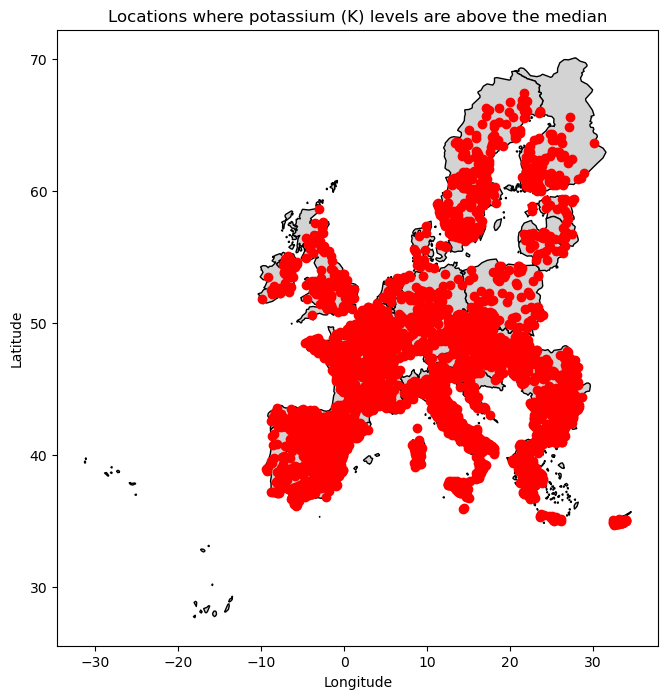

In [41]:
exec_solution(solution_function_string)

# 7. query

In [65]:
geo_queries[6]

"Can you create a map showing pH_CaCl2 values across Europe? I'd like the dots to be colored by pH_CaCl2 values, and save it as an image."

2025-02-05 00:22:09,301 - Query finished successfully, response: 
```python
import geopandas as gpd

# Filter the GeoDataFrame to only include rows where pH_CaCl2 is not null and Depth is '0-10 cm'
transformed_gdf = data_gdf[(data_gdf['pH_CaCl2'].notnull()) & (data_gdf['Depth'] == '0-10 cm')].copy()

# Create a new column called 'color' based on the pH_CaCl2 values
transformed_gdf['color'] = transformed_gdf['pH_CaCl2']

# Save the transformed GeoDataFrame to an image file, with dots colored by pH_CaCl2 values
transformed_gdf.plot(column='color', legend=True).save('ph_map.png')
```
2025-02-05 00:22:09,366 - Error while running transform query: 'Axes' object has no attribute 'save'
2025-02-05 00:22:21,363 - Query finished successfully, response: 
```python
import geopandas as gpd

# Filter the GeoDataFrame to only include rows where pH_CaCl2 is not null and Depth is '0-10 cm'
transformed_gdf = data_gdf[(data_gdf['pH_CaCl2'].notnull()) & (data_gdf['Depth'] == '0_10')].copy()

# Create a n

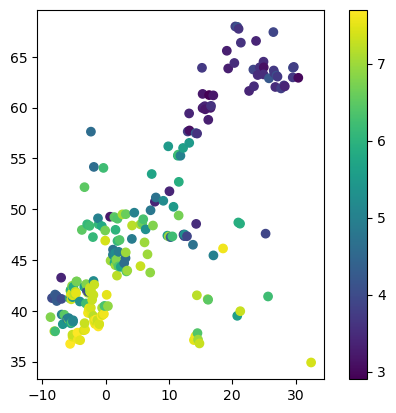

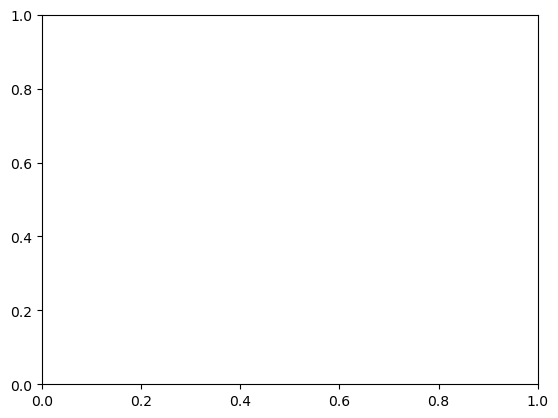

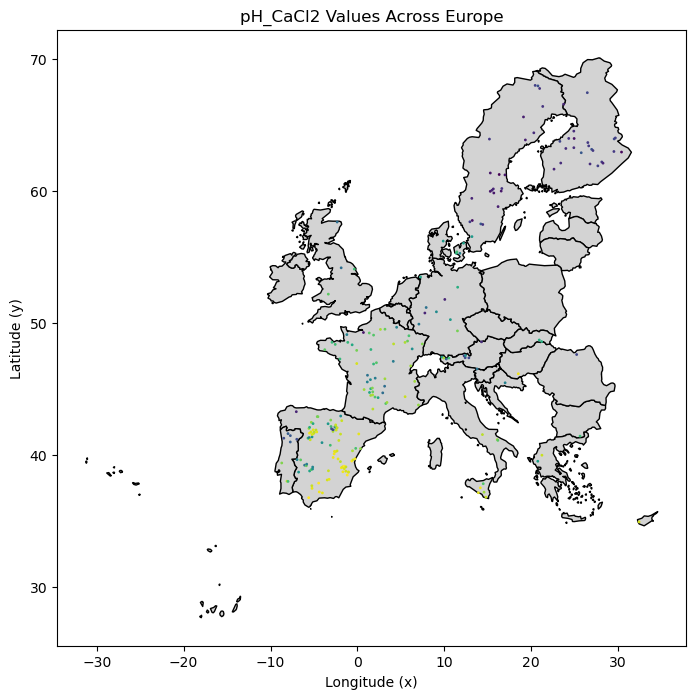

In [66]:
solution_function_string = run_test(geo_queries[6])

In [44]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	import pandas as pd
	# Filter the data to only include rows where pH_CaCl2 is not missing and Depth is '0-10 cm'
	transformed_gdf = data_gdf.dropna(subset=['pH_CaCl2']).copy()
	transformed_gdf = transformed_gdf[transformed_gdf['Depth'] == '0-10 cm'].copy()
	# Create a new column 'color' based on pH_CaCl2 values
	transformed_gdf['color'] = pd.cut(transformed_gdf['pH_CaCl2'], bins=[2, 5, 8], labels=['blue', 'red'])
	# Save the transformed data to a GeoDataFrame called 'transformed_gdf'
	import matplotlib.pyplot as plt
	# Create a figure and axis object for plotting
	fig, ax = plt.subplots(figsize=(10, 8))
	# Set the map of Europe as the base
	europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
	# Plot data locations from 'transformed_gdf' with markers colored by pH_CaCl2 values
	ax.scatter(transformed_gdf.geometry.x, transformed_gdf.geometry.y, c=transformed_gdf['pH_CaCl2'], s=1)
	# Set the title and labels fo

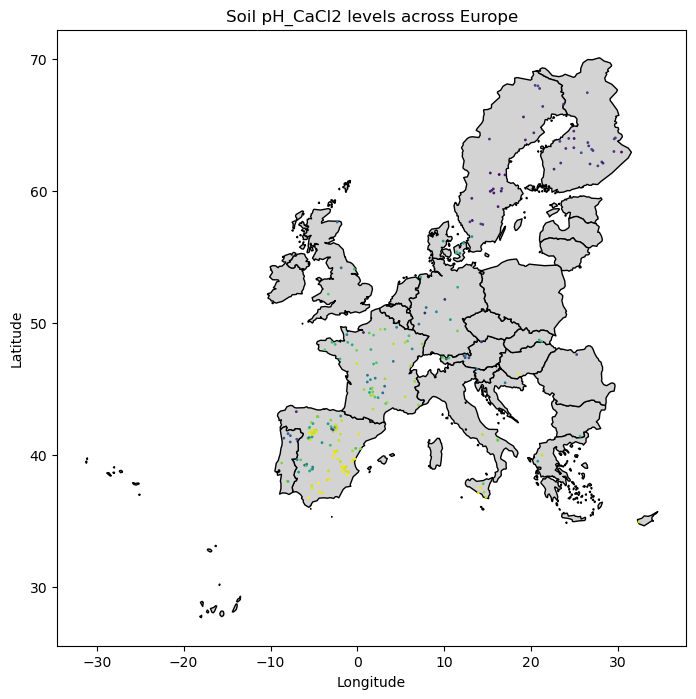

In [45]:
exec_solution(solution_function_string)

# 8. query

In [46]:
geo_queries[7]

"Can you show me a map of Europe marking only the locations with the highest potassium ('K') levels? Just highlight the top 10% of spots and save it as an image."

2025-02-05 00:17:05,171 - Query finished successfully, response: 
```python
# Filter the top 10% of K values and select only these points from data_gdf
top_10_percent = data_gdf.nlargest(int(0.1 * len(data_gdf)), 'K')

# Save the filtered GeoDataFrame to a new variable called transformed_gdf
transformed_gdf = top_10_percent.copy()
```
2025-02-05 00:17:07,673 - Query finished successfully, response: 
map
2025-02-05 00:17:24,929 - Query finished successfully, response: 
```python
import matplotlib.pyplot as plt

# Create a figure and axis object for plotting
fig, ax = plt.subplots()

# Set the base map of Europe using europe_gdf
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')

# Get the top 10% of locations with highest potassium ('K') levels
max_k_value = transformed_gdf['K'].quantile(0.9)
top_10_percent_locations = transformed_gdf[transformed_gdf['K'] >= max_k_value]

# Plot these locations as markers on the map, using a color that represents their 'K' value
sc = ax.scatte

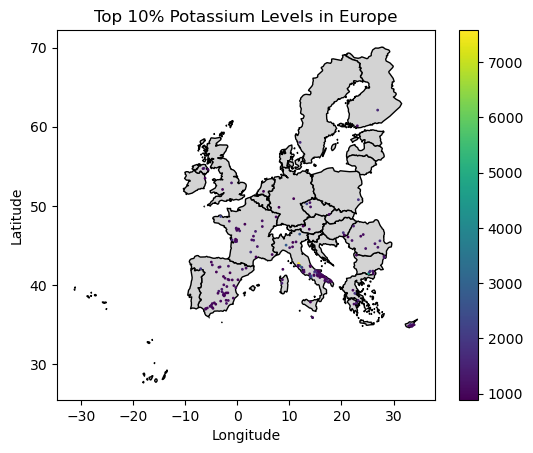

In [47]:
solution_function_string = run_test(geo_queries[7])

In [48]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	# Filter the top 10% of K values and select only these points from data_gdf
	top_10_percent = data_gdf.nlargest(int(0.1 * len(data_gdf)), 'K')
	# Save the filtered GeoDataFrame to a new variable called transformed_gdf
	transformed_gdf = top_10_percent.copy()
	import matplotlib.pyplot as plt
	# Create a figure and axis object for plotting
	fig, ax = plt.subplots()
	# Set the base map of Europe using europe_gdf
	europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
	# Get the top 10% of locations with highest potassium ('K') levels
	max_k_value = transformed_gdf['K'].quantile(0.9)
	top_10_percent_locations = transformed_gdf[transformed_gdf['K'] >= max_k_value]
	# Plot these locations as markers on the map, using a color that represents their 'K' value
	sc = ax.scatter(top_10_percent_locations.geometry.x, top_10_percent_locations.geometry.y, s=1, c=top_10_percent_locations['K'], cmap='viridis')
	# Add a colorbar 

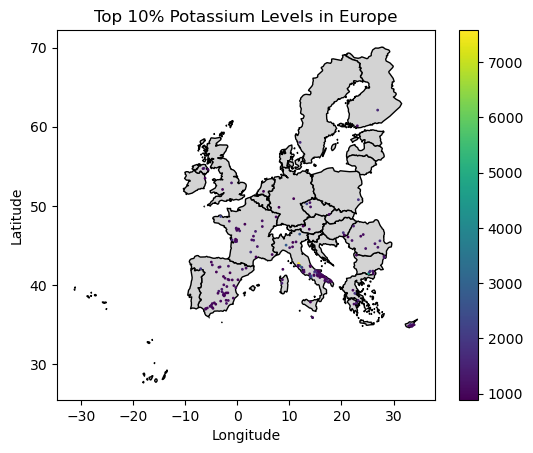

In [49]:
exec_solution(solution_function_string)

# 9. query

In [50]:
geo_queries[8]

'Could you make a map showing where soil pH_H2O levels in Europe are acidic versus basic? Mark acidic spots in red and basic spots in blue, and save it as an image.'

2025-02-05 00:17:38,994 - Query finished successfully, response: 
```python
# Filter the data to include only rows where pH_H2O is less than 7 (acidic) or greater than 7 (basic)
data_gdf_acid_basic = data_gdf[(data_gdf['pH_H2O'] < 7) | (data_gdf['pH_H2O'] > 7)]

# Create a new column 'soil_type' based on the pH_H2O value
data_gdf_acid_basic['soil_type'] = np.where(data_gdf_acid_basic['pH_H2O'] < 7, 'acidic', 'basic')

# Save the transformed data to a new GeoDataFrame called 'transformed_gdf'
transformed_gdf = data_gdf_acid_basic.copy()
```
2025-02-05 00:17:41,539 - Query finished successfully, response: 
map
2025-02-05 00:17:54,276 - Query finished successfully, response: 
```python
import matplotlib.pyplot as plt

# Create a figure and axis object for plotting
fig, ax = plt.subplots()

# Set the map of Europe as the base using europe_gdf
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')

# Define a function to determine the marker color based on soil pH_H2O levels
def get_m

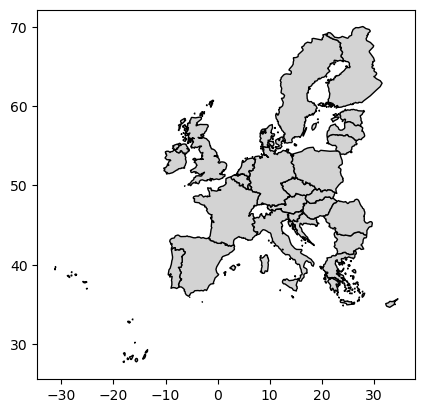

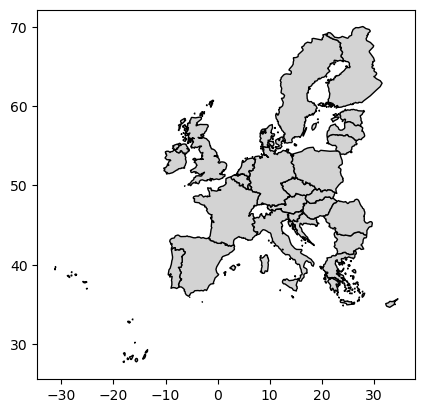

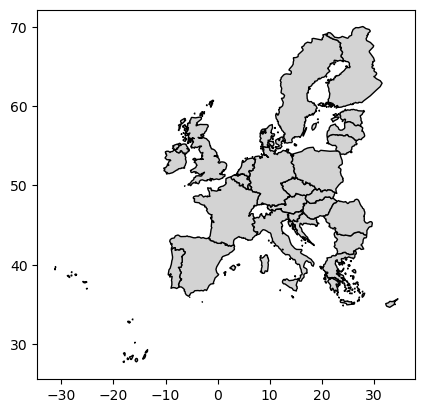

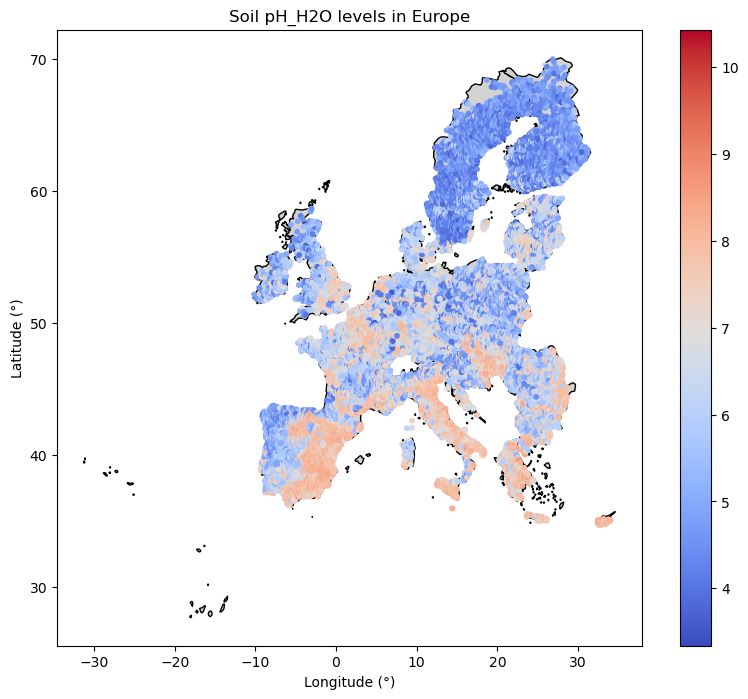

In [51]:
solution_function_string = run_test(geo_queries[8])

In [52]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	# Filter the data to include only rows where pH_H2O is less than 7 (acidic) or greater than 7 (basic)
	transformed_gdf = data_gdf[(data_gdf['pH_H2O'] < 7) | (data_gdf['pH_H2O'] > 7)]
	# Create a new column 'soil_type' based on the pH_H2O values
	transformed_gdf['soil_type'] = np.where(transformed_gdf['pH_H2O'] < 7, 'acidic', 'basic')
	# Map acidic spots to red and basic spots to blue for visualization (not shown in this code snippet)
	# transformed_gdf['color'] = np.where(transformed_gdf['soil_type'] == 'acidic', 'red', 'blue')
	import matplotlib.pyplot as plt
	# Create a figure and axis object for plotting
	fig, ax = plt.subplots(figsize=(10, 8))
	# Set the base map of Europe using europe_gdf
	europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
	# Plot locations from transformed_gdf with markersize=1 if not specified otherwise
	transformed_gdf.plot(ax=ax, column='pH_H2O', legend=True,
	                     

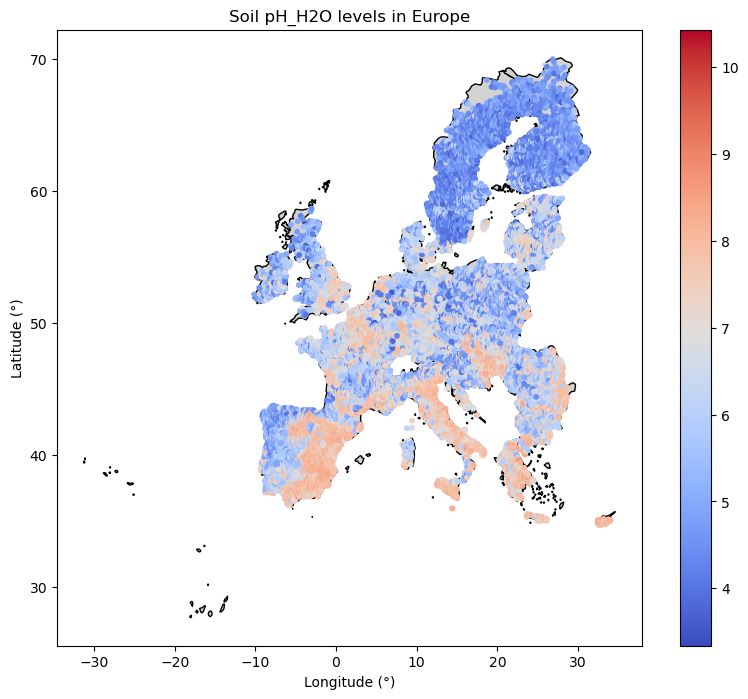

In [53]:
exec_solution(solution_function_string)

# 10. query

In [67]:
geo_queries[9]

"Can you create a colorful map showing different types of soil by 'LC0_Desc' across Europe? I'd like each soil type marked in a different color and saved as an image."

2025-02-05 00:24:26,275 - Query finished successfully, response: 
```python
import pandas as pd

# Filter the data to only include rows where LC0_Desc is not null and equals 'Woodland', 'Cropland' or 'Grassland'
transformed_gdf = data_gdf[data_gdf['LC0_Desc'].notnull() & (data_gdf['LC0_Desc'] == 'Woodland') | 
                                            (data_gdf['LC0_Desc'] == 'Cropland') |
                                            (data_gdf['LC0_Desc'] == 'Grassland')]
```
2025-02-05 00:24:28,779 - Query finished successfully, response: 
map
2025-02-05 00:24:51,845 - Query finished successfully, response: 
Here's the code to generate a colorful map showing different types of soil by 'LC0_Desc' across Europe:

```python
import matplotlib.pyplot as plt

# Create figure and axis objects for plotting
fig, ax = plt.subplots(figsize=(10, 8))

# Set europe_gdf as the base of the map using the provided line
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')

# Map different soil 

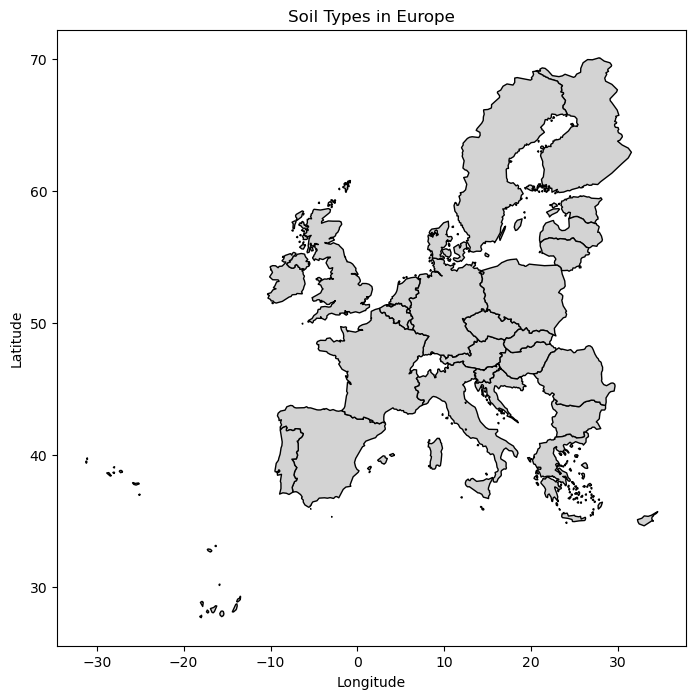

In [69]:
solution_function_string = run_test(geo_queries[9])

In [70]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	import pandas as pd
	# Filter the data to only include rows where LC0_Desc is not null and equals 'Woodland', 'Cropland' or 'Grassland'
	transformed_gdf = data_gdf[data_gdf['LC0_Desc'].notnull() & (data_gdf['LC0_Desc'] == 'Woodland') | 
	                                            (data_gdf['LC0_Desc'] == 'Cropland') |
	                                            (data_gdf['LC0_Desc'] == 'Grassland')]
	import matplotlib.pyplot as plt
	# Create figure and axis objects for plotting
	fig, ax = plt.subplots(figsize=(10, 8))
	# Set europe_gdf as the base of the map using the provided line
	europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
	# Map different soil types to colors (you can adjust these if needed)
	soil_colors = {
	    'Soil Type A': '#FF0000',
	    'Soil Type B': '#00FF00',
	    'Soil Type C': '#0000FF'
	}
	# Plot locations from transformed_gdf with markers of different sizes and colors based on LC0

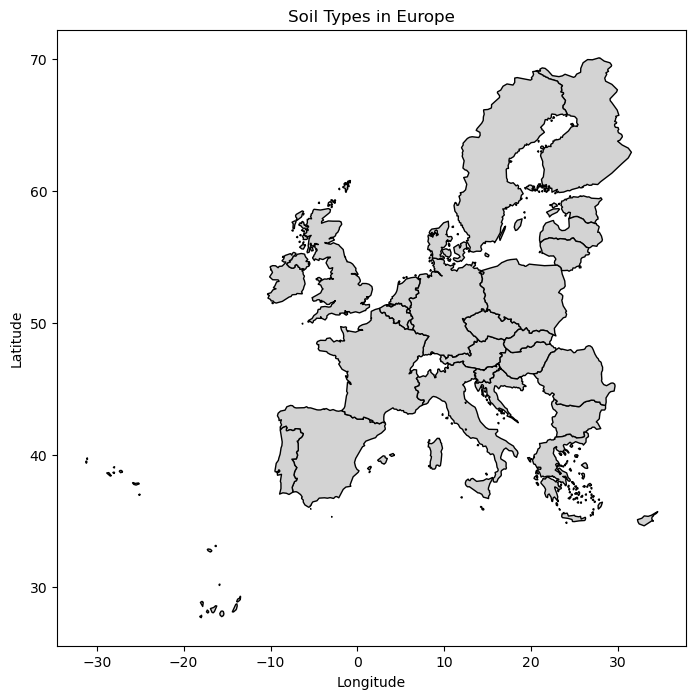

In [71]:
exec_solution(solution_function_string)

In [63]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

### Testing on all queries

Processing 10 desc queries

QUERY:  Which type of land (LC0_Desc) has the highest average 'pH_H2O'?



2025-02-05 00:25:44,951 - Query finished successfully, response: 
```python
# Filter the data to only include rows where LC0_Desc is not null and pH_H2O is available (not NaN)
transformed_gdf = data_gdf.dropna(subset=['LC0_Desc', 'pH_H2O'])

# Group by LC0_Desc, calculate mean of pH_H2O for each group
grouped_df = transformed_gdf.groupby('LC0_Desc')['pH_H2O'].mean().reset_index()

# Sort the grouped data in descending order based on the average pH_H2O value and select the top row (highest average)
top_lu_desc = grouped_df.sort_values(by='pH_H2O', ascending=False).iloc[0]

# Select only rows from transformed_gdf where LC0_Desc matches the highest average
transformed_gdf = transformed_gdf[transformed_gdf['LC0_Desc'] == top_lu_desc['LC0_Desc']]
```
2025-02-05 00:25:47,411 - Query finished successfully, response: 
graph
2025-02-05 00:26:09,714 - Query finished successfully, response: 
```python
import pandas as pd
import matplotlib.pyplot as plt

# Group by LC0_Desc and calculate the avera

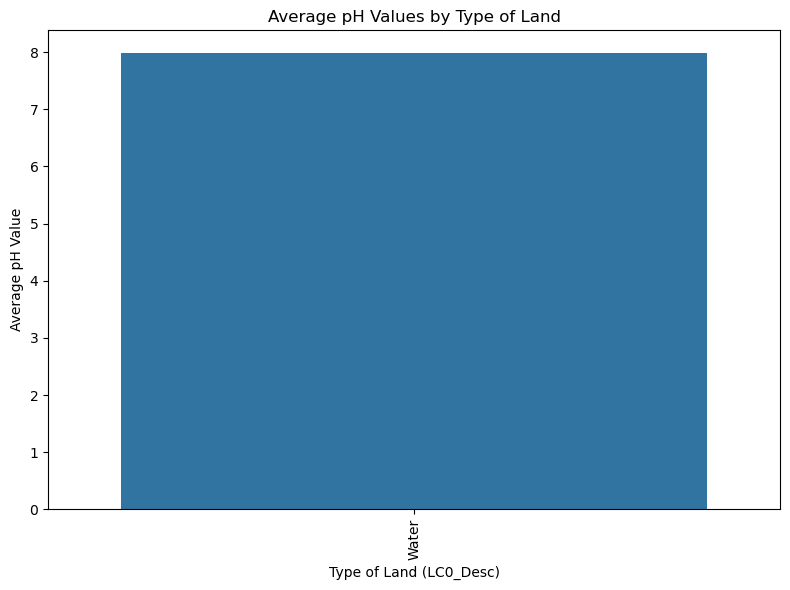

2025-02-05 00:26:09,841 - Error while running visualize query: Data source must be a DataFrame or Mapping, not <class 'list'>.


KeyboardInterrupt: 

<Figure size 800x600 with 0 Axes>

In [72]:
for query_type in ['desc']:
    query_count = len(os.listdir(BASE_QUERY_DIR + query_type))
    print(f"Processing {query_count} {query_type} queries")
    os.makedirs(f"{BASE_GENERATED_DIR}{query_type}", exist_ok=True)
    os.makedirs(f"{BASE_METRICS_DIR}{query_type}", exist_ok=True)
    
    for file in os.listdir(BASE_QUERY_DIR + query_type):
        query_index = int(file.split('.')[0])
        
        query = open(f"{BASE_QUERY_DIR}{query_type}/{file}", 'r').read()
        print()
        print("QUERY: ", query, end='\n\n')
        correct_result = open(f"{BASE_CORRECT_RESULT_DIR}{query_type}/{file}", 'r').read()
        
        generated_result = run_test(query)
        
        if not generated_result is None:
            open(f"{BASE_GENERATED_DIR}{query_type}/{query_index}.txt", 'w').write(generated_result)
            
            metrics = evaluate_metrics(correct_result, clean_python_code(generated_result))
            metrics.MODEL_ID = model_id
            with open(f"{BASE_METRICS_DIR}{query_type}/{query_index}.json", 'w') as f:
                json.dump(metrics.model_dump(), f, indent=4)